# EDA

## IMPORTAR PAQUETES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os
from pathlib import Path
import openpyxl
import sqlalchemy as sa

# Desactivar notación científica
pd.set_option('display.float_format', lambda x: '%.3f' % x)
np.set_printoptions(suppress=True)

# Cargar variables de entorno
load_dotenv()

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## IMPORTAR LOS DATOS

Cargar los datos.

In [2]:
cat = pd.read_pickle('../02_datos/03_Entrenamiento/cat_calidad.pkl')
num = pd.read_pickle('../02_datos/03_Entrenamiento/num_calidad.pkl')

## EDA CATEGÓRICAS

### Análisis estadístico

In [3]:
variables = ['antigüedad_empleo', 'ingresos_verificados', 'rating', 'vivienda',
       'finalidad', 'num_cuotas', 'estado']

In [4]:
def frecuencias_cat(df_cat):
    resultado = df_cat[variables].apply(lambda x: x.value_counts(normalize = True)).T.stack()\
                .to_frame().reset_index()\
                .rename(columns={'level_0':'Variable','level_1':'Valor',0: "Frecuencia"})\
                .sort_values(by = ['Variable','Frecuencia'])
    return(resultado)

Me concentro ahora en analizar los valores de las categoricas, las frecuencias las miro mejor con los gráficos

In [5]:
frecuencias_cat(cat)

,Variable,Valor,Frecuencia
11,antigüedad_empleo,9 years,0.035
10,antigüedad_empleo,8 years,0.041
9,antigüedad_empleo,7 years,0.042
8,antigüedad_empleo,6 years,0.045
6,antigüedad_empleo,4 years,0.061
...,...,...,...
207,vivienda,other,NaN
208,vivienda,renewable_energy,NaN
209,vivienda,small_business,NaN
210,vivienda,vacation,NaN


### Análisis gráfico

In [6]:
def graficos_eda_categoricos(cat):
    
    #Calculamos el número de filas que necesitamos
    from math import ceil
    filas = ceil(cat.shape[1] / 2)

    #Definimos el gráfico
    f, ax = plt.subplots(nrows = filas, ncols = 2, figsize = (16, filas * 6))

    #Aplanamos para iterar por el gráfico como si fuera de 1 dimensión en lugar de 2
    ax = ax.flat 

    #Creamos el bucle que va añadiendo gráficos
    for cada, variable in enumerate(cat):
        cat[variable].value_counts().plot.barh(ax = ax[cada])
        ax[cada].set_title(variable, fontsize = 12, fontweight = "bold")
        ax[cada].tick_params(labelsize = 12)

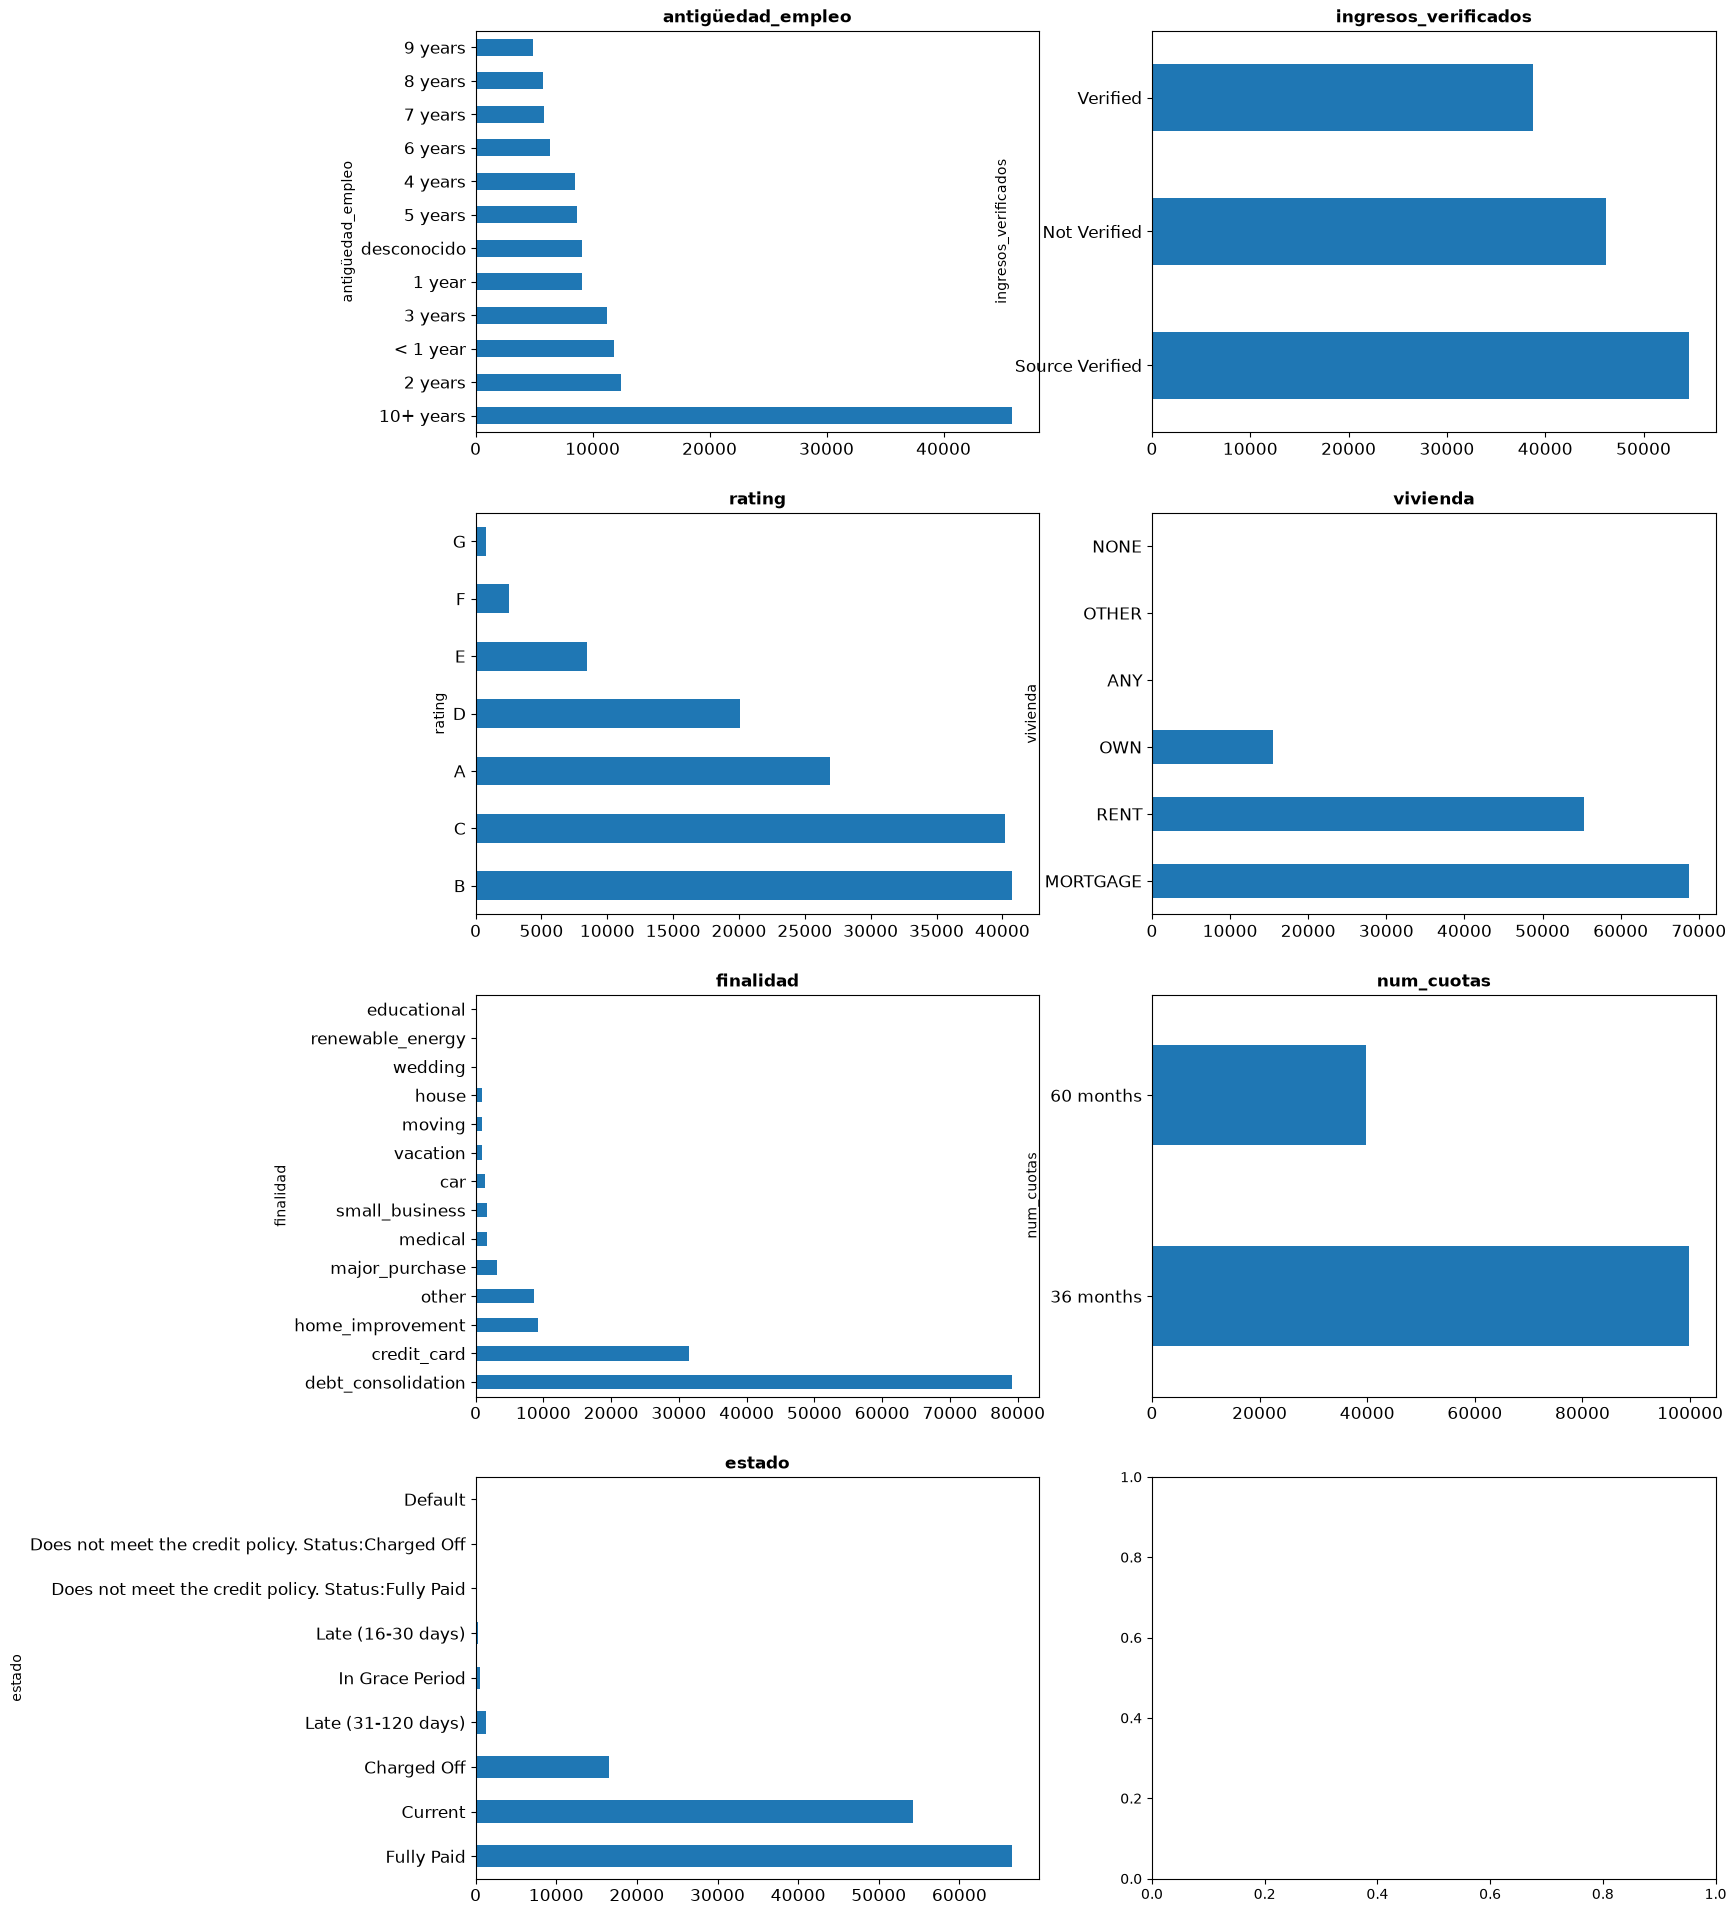

In [7]:
graficos_eda_categoricos(cat[variables])

Conclusiones:

* En vivienda junto ANY, NONE y OTHER a la categoria mayoritaria
* En finalidad junto renewable_energy, educational y wedding en 'otros'
* Creo la target a partir de estado

## EDA NUMÉRICAS

### Análisis estadístico

In [8]:
def estadisticos_cont(num):
    #Calculamos describe
    estadisticos = num.describe().T
    #Añadimos la mediana
    estadisticos['median'] = num.median()
    #Reordenamos para que la mediana esté al lado de la media
    estadisticos = estadisticos.iloc[:,[0,1,8,2,3,4,5,6,7]]
    #Lo devolvemos
    return(estadisticos)

In [9]:
estadisticos_cont(num)

,count,mean,median,std,min,25%,50%,75%,max
id_cliente,139603.000,80274678.595,84384476.000,44934647.121,65640.000,44956050.000,84384476.000,122295683.500,145640422.000
ingresos,139603.000,76219.877,65000.000,45453.451,0.000,46112.825,65000.000,93000.000,400000.000
dti,139603.000,18.835,17.830,14.327,-1.000,11.960,17.830,24.460,999.000
num_hipotecas,139603.000,1.514,1.000,1.884,0.000,0.000,1.000,2.000,32.000
num_lineas_credito,139603.000,11.620,11.000,5.632,0.000,8.000,11.000,14.000,84.000
porc_tarjetas_75p,139603.000,41.170,33.300,36.431,0.000,0.000,33.300,66.700,100.000
porc_uso_revolving,139603.000,50.388,50.400,24.654,0.000,31.700,50.400,69.300,184.600
num_cancelaciones_12meses,139603.000,0.008,0.000,0.103,0.000,0.000,0.000,0.000,7.000
num_derogatorios,139603.000,0.199,0.000,0.566,0.000,0.000,0.000,0.000,46.000
num_meses_desde_ult_retraso,139603.000,16.801,0.000,23.027,0.000,0.000,0.000,31.000,195.000


### Análisis gráfico

In [10]:
def graficos_eda_continuas(num):
    
    #Calculamos el número de fila que necesitamos
    from math import ceil
    filas = ceil(num.shape[1] / 2)

    #Definimos el gráfico
    f, ax = plt.subplots(nrows = filas, ncols = 2, figsize = (16, filas * 6))

    #Aplanamos para iterar por el gráfico como si fuera de 1 dimensión en lugar de 2
    ax = ax.flat 

    #Creamos el bucle que va añadiendo gráficos
    for cada, variable in enumerate(num):
        num[variable].plot.density(ax = ax[cada])
        ax[cada].set_title(variable, fontsize = 12, fontweight = "bold")
        ax[cada].tick_params(labelsize = 12)

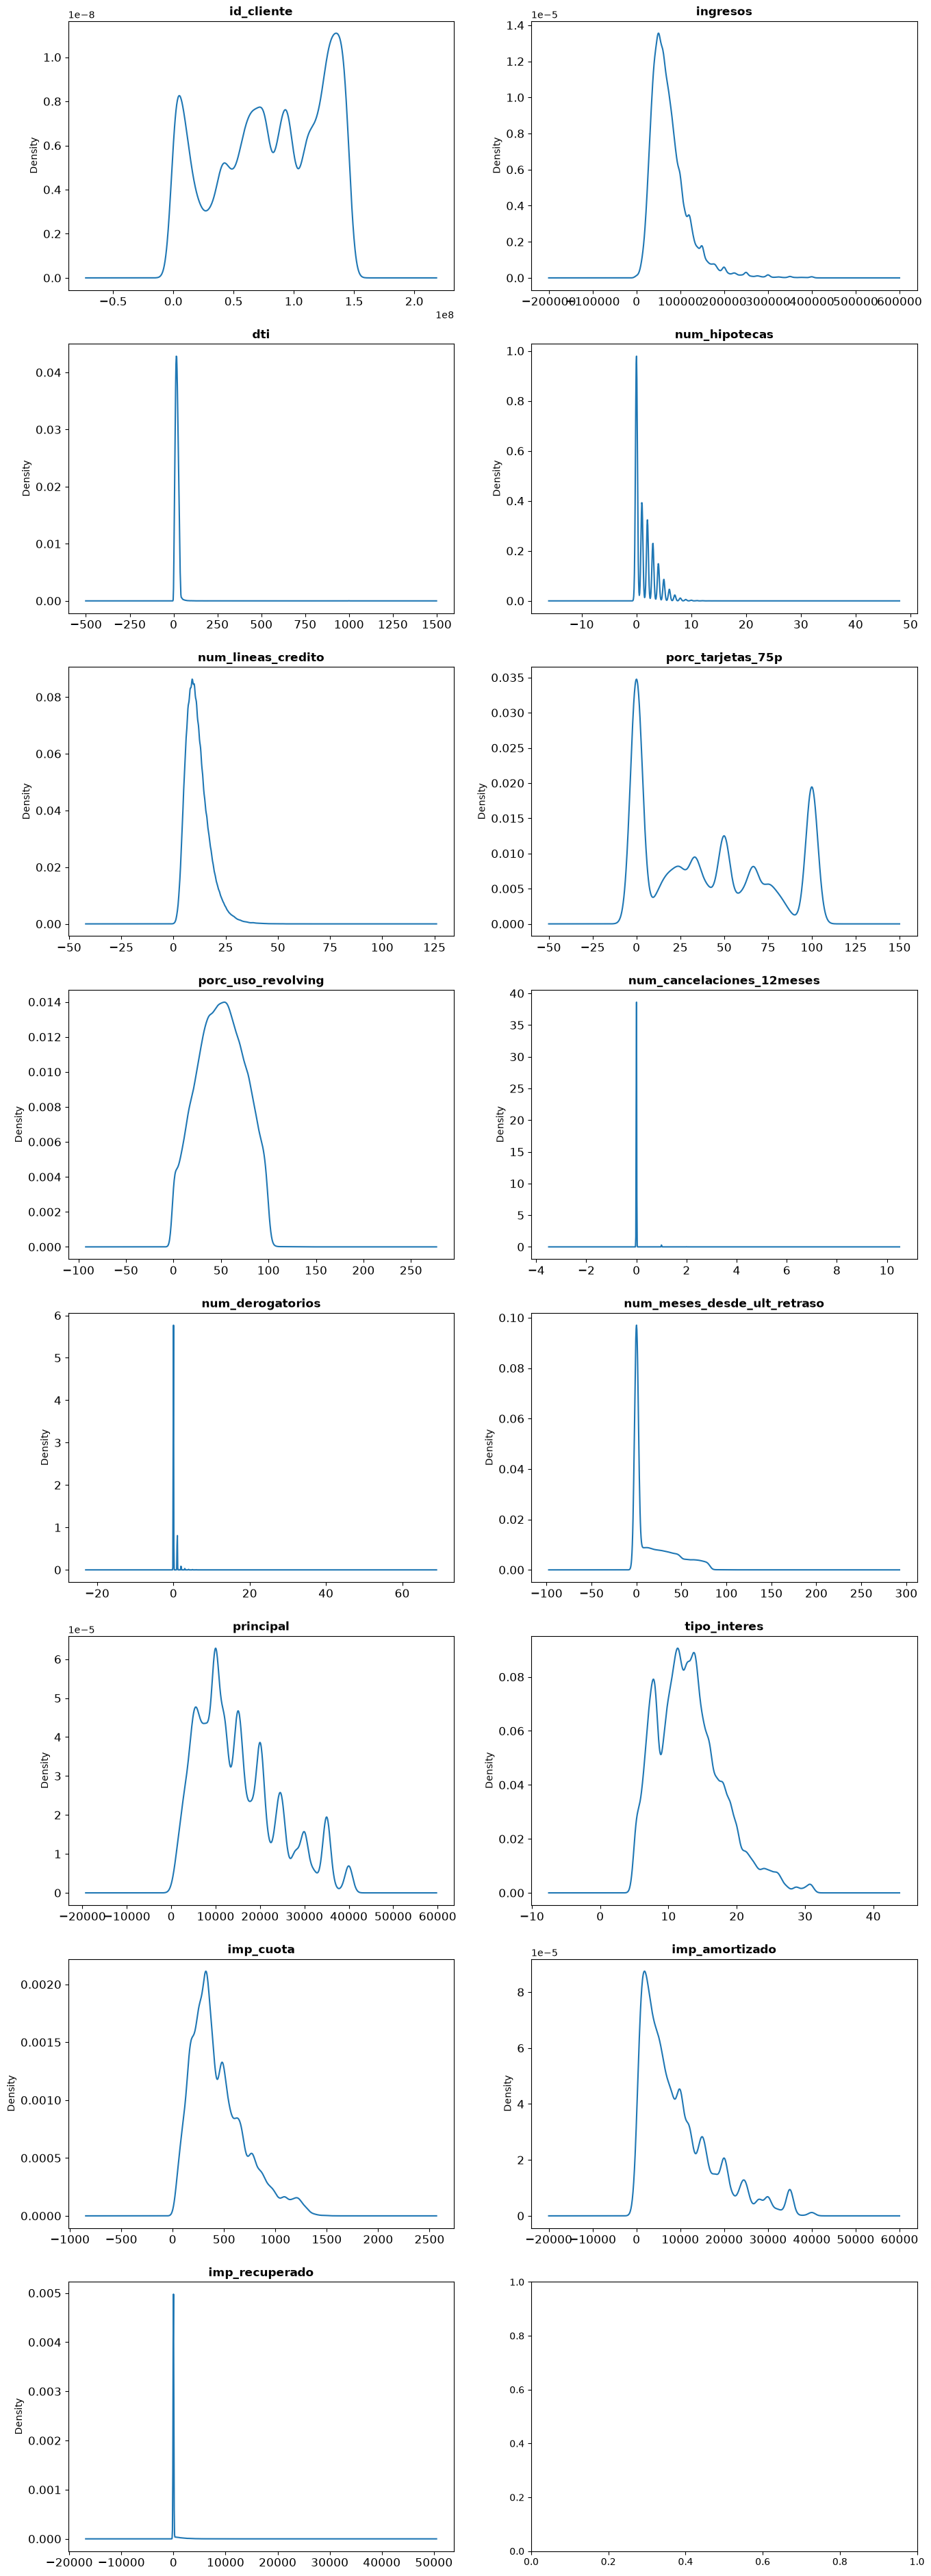

In [11]:
graficos_eda_continuas(num)

Vamos a analizar el detalle de imp_amortizado e imp_recuperado, ya que son relevantes para la target del modelo LGD.

In [12]:
ratios = num[['principal','imp_amortizado','imp_recuperado']].copy()

In [13]:
ratios['r_amortizado_principal'] = ratios.imp_amortizado / ratios.principal
ratios['r_recuperado_principal'] = ratios.imp_recuperado / ratios.principal

In [14]:
ratios.describe().T

,count,mean,std,min,25%,50%,75%,max
principal,139603.000,15035.854,9164.210,500.000,8000.000,12800.000,20000.000,40000.000
imp_amortizado,139603.000,9513.828,8306.570,0.000,3017.555,7000.000,13925.000,40000.000
imp_recuperado,139603.000,145.865,770.534,0.000,0.000,0.000,0.000,33666.340
r_amortizado_principal,139603.000,0.663,0.369,0.000,0.275,0.872,1.000,1.000
r_recuperado_principal,139603.000,0.009,0.041,0.000,0.000,0.000,0.000,1.221


## Conclusiones:

- DTI: valores negativos o superiores a 100 no tienen sentido de negocio y deben ser tratados como atípicos.
- num_hipotecas: valores superiores a 7 son extremadamente raros y probablemente errores.
- porc_uso_revolving: valores superiores a 100% no son posibles y deben considerarse errores.
- Para estas variables, se recomienda winsorizar a los límites indicados o eliminar los registros si el número de atípicos es muy bajo.
- En transformación convertir num_derogatorios a binaria
- Revisar en profundidad la relación entre estado e imp_recuperado

In [15]:
# Winsorización de variables numéricas con valores atípicos en el DataFrame num
import numpy as np

num['DTI'] = np.clip(num['dti'], 0, 100)
num['num_hipotecas'] = np.clip(num['num_hipotecas'], 0, 7)
num['porc_uso_revolving'] = np.clip(num['porc_uso_revolving'], 0, 100)


In [16]:
temp = cat[['estado']].merge(num[['imp_recuperado']], left_index=True, right_index=True)
temp.groupby('estado').imp_recuperado.mean()

estado
Charged Off                                           1231.894
Current                                                  0.000
Default                                                  0.000
Does not meet the credit policy. Status:Charged Off    332.336
Does not meet the credit policy. Status:Fully Paid       0.000
Fully Paid                                               0.000
In Grace Period                                          0.000
Late (16-30 days)                                        0.000
Late (31-120 days)                                       0.000
Name: imp_recuperado, dtype: float64

Efectivamente sólo hay importe recuperado en el estado Charged Off.

## GUARDAR DATASETS TRAS EDA

In [17]:
#Guardar los archivos
cat.to_pickle('../02_datos/03_Entrenamiento/cat_eda.pkl')
num.to_pickle('../02_datos/03_Entrenamiento/num_eda.pkl')